# Reproduced prefix trade-off figure

Shows the full concept-score range alongside a zoomed view of the high-score region, so the updated early-token trajectory remains legible while the baseline gap stays visible. Prompt is marked in purple. The figure is saved as a PDF under `figs/`.

Saved /home/xzascc/Documents/code/Prefix/figs/reproduced_prefix_tradeoff.pdf


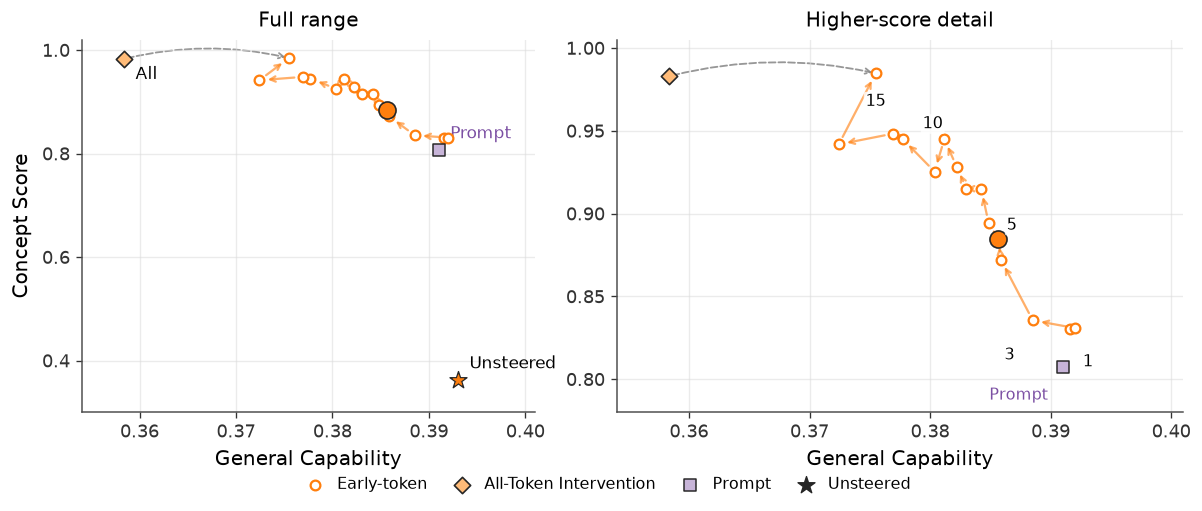

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from io import StringIO
from pathlib import Path

CSV_DATA = """series,prefix_len,general_capability,concept_score
Early-token,1,0.391573,0.8305
Early-token,2,0.391981,0.831017
Early-token,3,0.388518,0.835593
Early-token,4,0.385871,0.87229
Early-token,5,0.385667,0.884746
Early-token,6,0.384852,0.894407
Early-token,7,0.384241,0.915085
Early-token,8,0.383019,0.915085
Early-token,9,0.382205,0.928305
Early-token,10,0.381186,0.945085
Early-token,11,0.380372,0.925424
Early-token,12,0.377724,0.945085
Early-token,13,0.376909,0.948305
Early-token,14,0.372429,0.941864
Early-token,15,0.375484,0.984746
All-Token Intervention,,0.358376,0.98305
Unsteered,,0.392999,0.362712
Prompt,,0.390999,0.80732712
"""

df = pd.read_csv(StringIO(CSV_DATA))
early = df[df["series"] == "Early-token"].copy().sort_values("prefix_len")
all_pt = df[df["series"] == "All-Token Intervention"].iloc[0]
un_pt = df[df["series"] == "Unsteered"].iloc[0]
prompt_pt = df[df["series"] == "Prompt"].iloc[0]

orange = "#ff7f0e"
prompt_color = "#7B4FA3"

fig, (ax, ax_zoom) = plt.subplots(
    1, 2, figsize=(10.2, 4.5), dpi=120, sharex=True,
    gridspec_kw={"width_ratios": [1, 1.25]},
)

def draw_series(axis):
    xy = early[["general_capability", "concept_score"]].to_numpy()
    for (x0, y0), (x1, y1) in zip(xy[:-1], xy[1:]):
        axis.annotate(
            "", xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(
                arrowstyle="->", lw=1.35, color=orange, alpha=0.62,
                shrinkA=5, shrinkB=5, mutation_scale=8,
            ), zorder=2,
        )

    axis.add_patch(FancyArrowPatch(
        (all_pt.general_capability, all_pt.concept_score),
        (
            early.loc[early.prefix_len.eq(15), "general_capability"].item(),
            early.loc[early.prefix_len.eq(15), "concept_score"].item(),
        ),
        connectionstyle="arc3,rad=-0.12", arrowstyle="->", linestyle="--",
        mutation_scale=8, linewidth=1.1, color="0.55", alpha=0.9, zorder=1,
    ))
    axis.scatter(
        early["general_capability"], early["concept_score"],
        facecolors="white", edgecolors=orange, s=34, linewidths=1.35,
        label="Early-token", zorder=4,
    )
    axis.scatter(
        [all_pt.general_capability], [all_pt.concept_score], marker="D",
        s=48, facecolors="#ffbb78", edgecolors="0.15", linewidths=1.0,
        label="All-Token Intervention", zorder=5,
    )
    axis.scatter(
        [un_pt.general_capability], [un_pt.concept_score], marker="*",
        s=115, facecolors="0.15", edgecolors="0.15", linewidths=0.8,
        label="Unsteered", zorder=5,
    )
    axis.scatter(
        [un_pt.general_capability], [un_pt.concept_score], marker="*",
        s=48, facecolors=orange, edgecolors=orange, linewidths=0.5, zorder=6,
    )
    axis.scatter(
        [prompt_pt.general_capability], [prompt_pt.concept_score], marker="s",
        s=52, facecolors="#c7b4d8", edgecolors="0.15", linewidths=0.9,
        label="Prompt", zorder=6,
    )
    axis.scatter(
        [early.loc[early.prefix_len.eq(5), "general_capability"].item()],
        [early.loc[early.prefix_len.eq(5), "concept_score"].item()],
        s=105, facecolors=orange, edgecolors="0.15", linewidths=1.0, zorder=7,
    )


def style_axis(axis):
    axis.grid(True, color="0.86", linewidth=0.8, alpha=0.55)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color("0.3")
        axis.spines[side].set_linewidth(0.9)
    axis.tick_params(axis="both", labelsize=10.5, colors="0.2")


draw_series(ax)
draw_series(ax_zoom)

# Full range keeps all four baselines comparable.
ax.set_xlim(0.354, 0.401)
ax.set_ylim(0.30, 1.02)
ax.set_yticks([0.4, 0.6, 0.8, 1.0])
ax.set_title("Full range", fontsize=12, pad=8)
ax.annotate("All", (all_pt.general_capability, all_pt.concept_score),
            xytext=(7, -12), textcoords="offset points", fontsize=10)
ax.annotate("Prompt", (prompt_pt.general_capability, prompt_pt.concept_score),
            xytext=(7, 7), textcoords="offset points", fontsize=10, color=prompt_color)
ax.annotate("Unsteered", (un_pt.general_capability, un_pt.concept_score),
            xytext=(7, 7), textcoords="offset points", fontsize=10)

# The second panel magnifies the high-score region without hiding the baselines.
ax_zoom.set_xlim(0.354, 0.401)
ax_zoom.set_ylim(0.78, 1.005)
ax_zoom.set_yticks([0.8, 0.85, 0.9, 0.95, 1.0])
ax_zoom.set_title("Higher-score detail", fontsize=12, pad=8)

# Label a few representative prefix lengths with point-relative offsets.
label_offsets = {15: (0, -17), 10: (-7, 9), 5: (8, 8), 3: (-14, -21), 1: (11, -20)}
for prefix_len, offset in label_offsets.items():
    point = early.loc[early.prefix_len.eq(prefix_len)].iloc[0]
    ax_zoom.annotate(
        str(prefix_len),
        (point.general_capability, point.concept_score),
        xytext=offset, textcoords="offset points", fontsize=9.5,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.8),
        zorder=8,
    )
ax_zoom.annotate(
    "Prompt", (prompt_pt.general_capability, prompt_pt.concept_score),
    xytext=(-9, -17), textcoords="offset points", fontsize=9.5,
    ha="right", va="center", color=prompt_color,
    bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.8),
    zorder=8,
)

ax.set_xlabel("General Capability", fontsize=12, labelpad=5)
ax_zoom.set_xlabel("General Capability", fontsize=12, labelpad=5)
ax.set_ylabel("Concept Score", fontsize=12, labelpad=6)
style_axis(ax)
style_axis(ax_zoom)
ax_zoom.tick_params(labelleft=True)

handles, labels = ax.get_legend_handles_labels()
order = [labels.index(name) for name in ("Early-token", "All-Token Intervention", "Prompt", "Unsteered")]
fig.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc="lower center", bbox_to_anchor=(0.52, 0.015), ncol=4,
    frameon=False, fontsize=9.5, handlelength=1.2, columnspacing=1.6,
)
fig.subplots_adjust(left=0.09, right=0.99, top=0.88, bottom=0.19, wspace=0.16)

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "notebooks").is_dir() and (path / "figs").is_dir())
output_path = ROOT / "figs" / "reproduced_prefix_tradeoff.pdf"
fig.savefig(output_path, bbox_inches="tight")
print(f"Saved {output_path}")
plt.show()
